In [9]:
import sys
import os
sys.path.append('/root/capsule/code/beh_ephys_analysis')
from harp.clock import decode_harp_clock, align_timestamps_to_anchor_points
from open_ephys.analysis import Session
import datetime
from aind_ephys_rig_qc.temporal_alignment import search_harp_line
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from utils.plot_utils import combine_pdf_big

from open_ephys.analysis import Session
from pathlib import Path
import glob

import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from hdmf_zarr.nwb import NWBZarrIO
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U
import pandas as pd
import pickle
import scipy.stats as stats
from joblib import Parallel, delayed
from multiprocessing import Pool
from functools import partial
import time
import spikeinterface as si
import shutil 
import seaborn as sns
import math  
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import zscore
from trimesh import load_mesh
from scipy.optimize import minimize
from scipy.linalg import null_space
from joblib import Parallel, delayed
from matplotlib.colors import Normalize
from scipy.stats import rankdata
import scanpy as sc

%matplotlib inline

In [10]:
target_folder = '/root/capsule/scratch/manuscript/F_spatial_axis_compare'

In [11]:
ml, ap, dv = 0, 1, 2
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

In [12]:
# load waveform info
waveform_file = '/root/capsule/scratch/manuscript/F_waveform_space/combined_features_waveform_all.csv'
wf_combined_features = pd.read_csv(waveform_file)
wf_feature_focus = 'wf_pc_1'
wf_features_focus = [
                'post_w', 
                'trough_post_ratio_1D', 
                'post_trough_slope', 
                'pre_slope',
                'symmetry_slope_div_log',
                'symmetry_trough_dis', 
                'symmetry_inte_div_log', 
                ]

ccf_wf = wf_combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values
ccf_wf = ccf_wf - bregma_LPS_mm
ccf_wf[:, ml] = np.abs(ccf_wf[:, ml])  # mirror ML to left

filter_wf = ~np.isnan(wf_combined_features[wf_feature_focus].values) & ~np.any(np.isnan(ccf_wf), axis=1)
feature_x = wf_combined_features[wf_feature_focus].values[filter_wf]
features_x = wf_combined_features[wf_features_focus].values[filter_wf]
coord_x = ccf_wf[filter_wf].copy()                                                                                                                                                                                                                                             

In [13]:
# load pseudo cluster info
data_dir = '~/capsule/scratch/combined/merfish/spatial_with_pseudocluster.csv'
merfish_ccf = pd.read_csv(data_dir)
ccf_merfish = merfish_ccf[['AP', 'DV', 'ML']].values
ccf_merfish = ccf_merfish/25
ccf_merfish = ccf_pts_convert_to_mm(ccf_merfish)
ccf_merfish= pir_to_lps(ccf_merfish)

ccf_merfish[:, ml] = np.abs(ccf_merfish[:, ml])  # mirror ML to left
ccf_merfish[:, ap] = -ccf_merfish[:, ap]  # flip AP to match atlas orientation

filter = (ccf_merfish[:, dv]>-5)
feature_y = merfish_ccf['pseudocluster'].values[filter]
coord_y = ccf_merfish[filter, :]

In [14]:
# load gene expression info
MERFISH_DATA_DIR  = '/root/capsule/data/merfish_data/adata'

def load_and_preprocess_data():
    """Load  MERFISH data, perform initial preprocessing""" # not laoding mesh for this
    
    # allmeshes = utils.load_mesh(MESH_DIR, nameconstrains = '*new_core*')
    # mesh = allmeshes['new_core_mesh']
    # mesh.vertices = mesh.vertices[:, [1,2, 0]]  # they somehow swapped the order -_-
    # mesh.vertices /= 25  # Scale vertices to mm
    
    print("Loading MERFISH data...")
    filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_2k.h5ad')    
    adata_mer = sc.read_h5ad(filename)
    librarysize = np.sum(adata_mer.X, 1)
    normed_x = 1000*adata_mer.X/librarysize[:,None]
    adata_mer.X = normed_x

    # some removal of the ventral cell
    y = adata_mer.obsm["spatial"][:, 1]
    keep = y <= 220
    print(f"Removing {(~keep).sum()} cells with DV axis > 220")  # this shoudl show 41
    adata_mer = adata_mer[keep].copy()
    print(f"After filtering: {adata_mer.shape}")  # this should be 2221
    return _, _, adata_mer

_, _, adata_mer = load_and_preprocess_data()

features_y = adata_mer.X
coord_y = adata_mer.obsm['spatial']
coord_y_mm = ccf_pts_convert_to_mm(coord_y)
coord_y_mm= pir_to_lps(coord_y_mm)
coord_y_mm[:, ml] = np.abs(coord_y_mm[:, ml])  # mirror ML to left
coord_y_mm[:, ap] = -coord_y_mm[:, ap]  # flip AP to match atlas orientation
filter = (coord_y_mm[:, dv]>-10)
features_y = features_y[filter]
coord_y = coord_y_mm[filter, :]


# extract PC1 from features_y as feature y
pca = PCA(n_components=1)
feature_y_pc1 = pca.fit_transform(features_y).flatten()
feature_y = feature_y_pc1


Loading MERFISH data...
Removing 41 cells with DV axis > 220
After filtering: (2221, 315)


In [15]:
# load retro data
data_dir = '/root/capsule/scratch/combined/retro_ccf/manual_proofread_ccf_18brains.csv'
retro_ccf = pd.read_csv(data_dir)
bregma_pixel_retro = np.array([228, 18, 216])
ccf_retro = (retro_ccf[['x', 'y', 'z']].values - bregma_pixel_retro) * 25 / 1000  # convert to mm
ccf_retro[:, [dv, ap]] = ccf_retro[:, [ap, dv]]  # Mirror ML to left
ccf_retro[:, dv] = -ccf_retro[:, dv]  # Mirror ML to left
ccf_retro[:, ml] = np.abs(ccf_retro[:, ml])  # Mirror ML to left
filter = (retro_ccf['injection_region'].values != 'TH') & (ccf_retro[:, dv]>-5)
feature_z = retro_ccf['injection_region'].values[filter]
cat = pd.Categorical(feature_z)
feature_z = cat.codes
categories = cat.categories
coord_z = ccf_retro[filter, :]

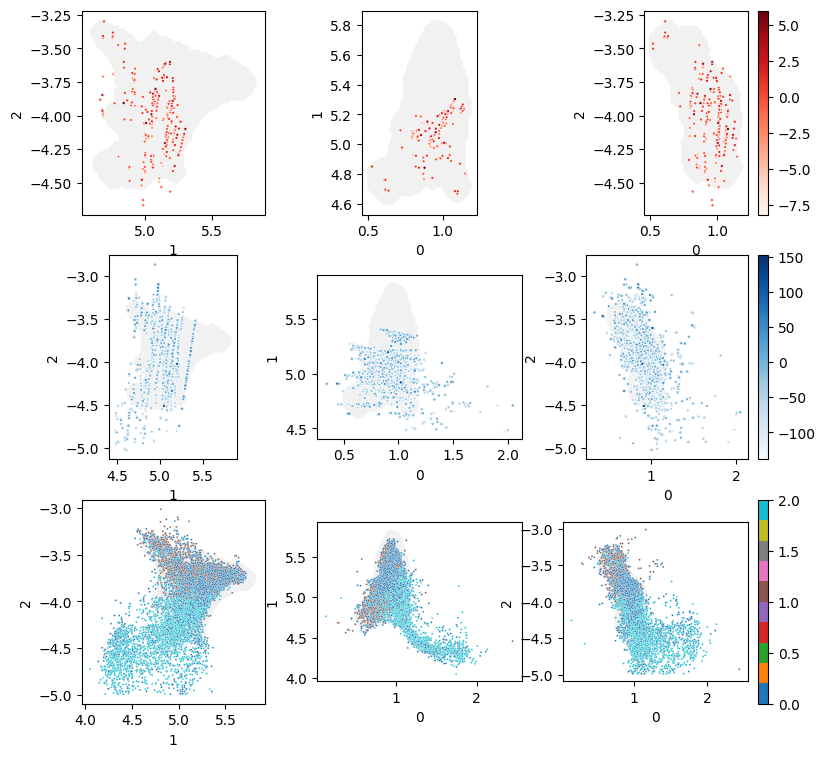

In [16]:
# plot together
fig, axes = plt.subplots(3, 3, figsize=(9, 9), squeeze=False)

for plane, ax in zip(planes.keys(), axes[0, :]):
    # Plot the mesh
    for c in mesh_contours[plane]:
        ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    # Plot the points
    # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], s=0.1, edgecolor = 'none', color = 'k')
    sc = ax.scatter(coord_x[:, planes[plane][0]], coord_x[:, planes[plane][1]], c=feature_x, cmap='Reds', s=5, edgecolor=[1, 1, 1], alpha=1, linewidth=0.5)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    # if planes[plane][1] == dv: 
    #     ax.invert_yaxis()
        # ax.set_ylim(-5, -3)
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)

for plane, ax in zip(planes.keys(), axes[1, :]):
    # Plot the mesh
    for c in mesh_contours[plane]:
        ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    # Plot the points
    sc = ax.scatter(coord_y[:, planes[plane][0]], coord_y[:, planes[plane][1]], c=feature_y, cmap='Blues', s=5, edgecolor=[1, 1, 1], alpha=1, linewidth=0.5)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    # if planes[plane][1] == dv: 
    #     ax.invert_yaxis()
        # ax.set_ylim(-5, -3)
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)

for plane, ax in zip(planes.keys(), axes[2, :]):
    # Plot the mesh
    for c in mesh_contours[plane]:
        ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    # Plot the points
    sc = ax.scatter(coord_z[:, planes[plane][0]], coord_z[:, planes[plane][1]], c=feature_z, cmap='tab10', s=2, edgecolor=[1, 1, 1], alpha=1, linewidth=0.2)
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    # set equal aspect ratio
    ax.set_aspect('equal')
    # if planes[plane][1] == dv: 
    #     ax.invert_yaxis()
        # ax.set_ylim(-5, -3)
    if plane == 'cor':
        fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2



def _unit(v, eps=1e-15):
    v = np.asarray(v, dtype=float).reshape(-1)
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Cannot normalize a near-zero vector.")
    return v / n


def fit_spatial_axis_linear(
    feature,
    coords,
    *,
    add_intercept=True,
    center_coords=False,
    center_feature=False,
    return_model_details=False,
):
    """
    Fit a linear model:
        feature ~= intercept + coords @ beta

    and return the spatial axis beta normalized to a unit vector.

    Parameters
    ----------
    feature : array-like, shape (n,)
    coords : array-like, shape (n, 3)
    add_intercept : bool
        If True, fit an intercept.
    center_coords : bool
        If True, subtract mean from coords before fitting.
    center_feature : bool
        If True, subtract mean from feature before fitting.
    return_model_details : bool
        If True, also return raw beta, intercept, fitted values, residuals, etc.

    Returns
    -------
    result : dict
        result["axis_unit"] : unit vector of beta
        result["beta"]      : raw 3D regression coefficient vector
        result["intercept"] : scalar intercept
        plus optional diagnostics if return_model_details=True
    """
    y = np.asarray(feature, dtype=float).reshape(-1)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if len(y) != len(X):
        raise ValueError("feature and coords must have the same length.")

    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[ok]
    X = X[ok]

    if len(y) < 4:
        raise ValueError("Need at least 4 valid samples.")

    X_used = X.copy()
    y_used = y.copy()

    coords_mean = X_used.mean(axis=0) if center_coords else np.zeros(3)
    feature_mean = y_used.mean() if center_feature else 0.0

    if center_coords:
        X_used = X_used - coords_mean
    if center_feature:
        y_used = y_used - feature_mean

    if add_intercept:
        X_design = np.column_stack([np.ones(len(X_used)), X_used])
        coef = np.linalg.lstsq(X_design, y_used, rcond=None)[0]
        intercept = float(coef[0])
        beta = coef[1:]
        y_hat = X_design @ coef
    else:
        X_design = X_used
        beta = np.linalg.lstsq(X_design, y_used, rcond=None)[0]
        intercept = 0.0
        y_hat = X_design @ beta

    beta = np.asarray(beta, dtype=float).reshape(3)
    axis_unit = _unit(beta)
    residuals = y_used - y_hat

    result = {
        "axis_unit": axis_unit,
        "beta": beta,
        "intercept": intercept,
    }

    if return_model_details:
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_used - y_used.mean()) ** 2)
        r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

        result.update({
            "coords_mean": coords_mean,
            "feature_mean": feature_mean,
            "fitted": y_hat,
            "residuals": residuals,
            "r2": r2,
            "n_valid": len(y_used),
        })

    return result


def bootstrap_spatial_axis_linear(
    feature,
    coords,
    *,
    n_boot=5000,
    seed=0,
    add_intercept=True,
    center_coords=False,
    center_feature=False,
    align_to_observed=True,
    min_norm=1e-12,
    return_full=False,
):
    """
    Fit a spatial regression axis from feature ~ coords, convert to unit vector,
    then bootstrap rows to generate bootstrap unit vectors.

    Bootstrap vectors are optionally flipped so that their dot product with the
    observed axis is positive.

    Parameters
    ----------
    feature : array-like, shape (n,)
    coords : array-like, shape (n, 3)
    n_boot : int
        Number of bootstrap resamples.
    seed : int
        Random seed.
    add_intercept : bool
        If True, fit an intercept in each regression.
    center_coords : bool
        If True, center coords before fitting.
    center_feature : bool
        If True, center feature before fitting.
    align_to_observed : bool
        If True, flip bootstrap vectors so dot(v_boot, v_obs) > 0.
    min_norm : float
        Minimum raw beta norm allowed before normalization.
    return_full : bool
        If True, also return raw bootstrap betas and intercepts.

    Returns
    -------
    result : dict
        result["axis_unit"]        : observed fitted unit vector, shape (3,)
        result["beta"]             : observed raw beta, shape (3,)
        result["intercept"]        : observed intercept
        result["axis_boot"]        : bootstrap unit vectors, shape (n_valid_boot, 3)
        result["beta_boot"]        : bootstrap raw beta vectors, optional
        result["intercept_boot"]   : bootstrap intercepts, optional
        result["n_boot_valid"]     : number of successful bootstrap fits
        result["n_boot_failed"]    : number of failed bootstrap fits
    """
    y = np.asarray(feature, dtype=float).reshape(-1)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if len(y) != len(X):
        raise ValueError("feature and coords must have the same length.")

    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[ok]
    X = X[ok]

    n = len(y)
    if n < 4:
        raise ValueError("Need at least 4 valid samples.")

    obs = fit_spatial_axis_linear(
        y,
        X,
        add_intercept=add_intercept,
        center_coords=center_coords,
        center_feature=center_feature,
        return_model_details=False,
    )
    axis_obs = obs["axis_unit"]
    beta_obs = obs["beta"]
    intercept_obs = obs["intercept"]

    rng = np.random.default_rng(seed)

    axis_boot = []
    beta_boot = []
    intercept_boot = []
    failed = 0

    for _ in range(n_boot):
        ind = rng.integers(0, n, size=n)
        yb = y[ind]
        Xb = X[ind]

        try:
            res_b = fit_spatial_axis_linear(
                yb,
                Xb,
                add_intercept=add_intercept,
                center_coords=center_coords,
                center_feature=center_feature,
                return_model_details=False,
            )

            beta_b = np.asarray(res_b["beta"], dtype=float).reshape(3)
            if np.linalg.norm(beta_b) < min_norm:
                failed += 1
                continue

            axis_b = np.asarray(res_b["axis_unit"], dtype=float).reshape(3)

            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
                beta_b = -beta_b
                # do not flip intercept; sign flip only changes axis orientation

            axis_boot.append(axis_b)
            beta_boot.append(beta_b)
            intercept_boot.append(res_b["intercept"])

        except Exception:
            failed += 1
            continue

    axis_boot = np.asarray(axis_boot, dtype=float)

    result = {
        "axis_unit": axis_obs,
        "beta": beta_obs,
        "intercept": intercept_obs,
        "axis_boot": axis_boot,
        "n_boot_valid": len(axis_boot),
        "n_boot_failed": failed,
    }

    if return_full:
        result["beta_boot"] = np.asarray(beta_boot, dtype=float)
        result["intercept_boot"] = np.asarray(intercept_boot, dtype=float)

    return result

def vectors_to_az_el(vectors, degrees=True):
    """
    Convert 3D unit vectors to azimuth and elevation.

    Parameters
    ----------
    vectors : array (n,3)

    Returns
    -------
    azimuth : (n,)
    elevation : (n,)
    """

    v = np.asarray(vectors)

    x = v[:,0]
    y = v[:,1]
    z = v[:,2]

    az = np.arctan2(y, x)
    el = np.arcsin(np.clip(z, -1, 1))

    if degrees:
        az = np.degrees(az)
        el = np.degrees(el)

    return az, el


def plot_vector_distribution_az_el(
    axis_boot,
    axis_obs=None,
    bins=50,
    figsize=(10,4)
):
    """
    Plot bootstrap vector directions in azimuth/elevation space.
    """

    az, el = vectors_to_az_el(axis_boot)

    fig, axes = plt.subplots(1,2, figsize=figsize)

    # azimuth distribution
    axes[0].hist(az, bins=bins)
    axes[0].set_xlabel("Azimuth (deg)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Bootstrap azimuth")

    # elevation distribution
    axes[1].hist(el, bins=bins)
    axes[1].set_xlabel("Elevation (deg)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Bootstrap elevation")

    if axis_obs is not None:
        az_obs, el_obs = vectors_to_az_el(axis_obs.reshape(1,3))
        axes[0].axvline(az_obs[0])
        axes[1].axvline(el_obs[0])

    plt.tight_layout()

def plot_vector_distribution_az_el_2d(axis_boot, axis_obs, color, ax=None):

    az, el = vectors_to_az_el(axis_boot)

    if ax is None:

        fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(az, el, s=2, alpha=1, color=color, edgecolor='w', linewidth=0.5)

    if axis_obs is not None:
        az_obs, el_obs = vectors_to_az_el(axis_obs.reshape(1,3))
        ax.scatter(az_obs, el_obs, s=120, marker='x')

    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Elevation (deg)")
    ax.set_title("Bootstrap spatial axis distribution")
    ax.set_aspect('equal')
    return ax



def _unit(v, eps=1e-15):
    v = np.asarray(v, dtype=float).reshape(-1)
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Cannot normalize near-zero vector.")
    return v / n


def _orthonormal_basis_perp(v0, v1):
    """
    Construct orthonormal basis where:

    u0 = normalized v0
    e1 = direction of maximal difference between v0 and v1
         (projection of v1 onto plane perpendicular to v0)
    e2 = perpendicular to both u0 and e1
    """

    u0 = _unit(v0)

    # remove component of v1 along v0
    diff = v1 - np.dot(v1, u0) * u0

    # handle nearly parallel vectors
    if np.linalg.norm(diff) < 1e-12:
        if abs(u0[0]) < 0.9:
            a = np.array([1.0, 0.0, 0.0])
        else:
            a = np.array([0.0, 1.0, 0.0])
        diff = a - np.dot(a, u0) * u0

    e1 = _unit(diff)

    # second orthogonal direction
    e2 = np.cross(u0, e1)
    e2 = _unit(e2)

    return e1, e2, u0


def compare_bootstrap_directions(
    b_x,
    b_y,
    b_x_boot,
    b_y_boot,
    *,
    assume_paired=True,
    flip_to_observed=True,
):
    """
    Compare whether two 3D unit-vector directions are different using bootstrap.
    """
    import numpy as np
    from scipy.stats import chi2

    b_x = _unit(b_x)
    b_y = _unit(b_y)
    b_x_boot = np.asarray(b_x_boot, float)
    b_y_boot = np.asarray(b_y_boot, float)

    if b_x_boot.shape != b_y_boot.shape or b_x_boot.shape[1] != 3:
        raise ValueError("b_x_boot and b_y_boot must both have shape (n_boot, 3).")

    valid_x = np.all(np.isfinite(b_x_boot), axis=1) & (np.linalg.norm(b_x_boot, axis=1) > 0)
    valid_y = np.all(np.isfinite(b_y_boot), axis=1) & (np.linalg.norm(b_y_boot, axis=1) > 0)
    valid = valid_x & valid_y
    b_x_boot = b_x_boot[valid]
    b_y_boot = b_y_boot[valid]

    b_x_boot = b_x_boot / np.linalg.norm(b_x_boot, axis=1, keepdims=True)
    b_y_boot = b_y_boot / np.linalg.norm(b_y_boot, axis=1, keepdims=True)

    if flip_to_observed:
        flip_x = np.sum(b_x_boot * b_x[None, :], axis=1) < 0
        flip_y = np.sum(b_y_boot * b_y[None, :], axis=1) < 0
        b_x_boot[flip_x] *= -1
        b_y_boot[flip_y] *= -1

    # tangent plane at b_x, with e1 aligned to observed difference toward b_y
    e1, e2, u0 = _orthonormal_basis_perp(b_x, b_y)
    A = np.vstack([e1, e2])  # 2 x 3

    # observed 2D deviation of y away from x-axis
    d_obs = A @ b_y
    Px = (A @ b_x_boot.T).T   # shape (nx, 2)
    Py = (A @ b_y_boot.T).T   # shape (ny, 2)

    if assume_paired:
        if len(Px) != len(Py):
            raise ValueError("Paired bootstrap requires the same number of bootstrap samples.")
        d_boot = Py - Px
    else:
        n_pair = min(10000, len(Px) * len(Py))
        rng = np.random.default_rng(0)
        ix = rng.integers(0, len(Px), size=n_pair)
        iy = rng.integers(0, len(Py), size=n_pair)
        d_boot = Py[iy] - Px[ix]

    mean_boot = d_boot.mean(axis=0)

    # covariance estimated from ordinary bootstrap
    cov_2d = np.cov(d_boot.T, ddof=1)
    cov_2d += np.eye(2) * 1e-12
    cov_inv = np.linalg.inv(cov_2d)

    # observed Wald statistic against null d = 0
    W_obs = float(d_obs.T @ cov_inv @ d_obs)
    p_chi2 = 1 - chi2.cdf(W_obs, df=2)

    p_chi2 = chi2.sf(W_obs, df=2)

    # --------bootstrap p-value --------.
    d_boot_null = d_boot - mean_boot[None, :]
    W_boot_null = np.einsum("ni,ij,nj->n", d_boot_null, cov_inv, d_boot_null)
    p_boot = (np.sum(W_boot_null >= W_obs) + 1) / (len(W_boot_null) + 1)
    # ----------------------------------------
    # 95% ellipse check for zero
    from scipy.stats import chi2
    thr95 = chi2.ppf(0.95, df=2)
    cos_angle = np.clip(np.dot(b_x, b_y), -1, 1)
    angle_deg = np.degrees(np.arccos(cos_angle))

    ci95_e1 = np.percentile(d_boot[:, 0], [2.5, 97.5])
    ci95_e2 = np.percentile(d_boot[:, 1], [2.5, 97.5])

    delta0 = -mean_boot
    maha2_zero = float(delta0.T @ cov_inv @ delta0)
    zero_inside_95ci = maha2_zero <= thr95


    return {
        "d_obs": d_obs,
        "d_boot": d_boot,
        "d_boot_null": d_boot_null,
        "mean_boot": mean_boot,
        "cov_2d": cov_2d,
        "W_obs": W_obs,
        "W_boot_null": W_boot_null,
        "p_chi2": p_chi2,
        "p_boot": p_boot,
        "angle_deg": angle_deg,
        "basis_e1": e1,
        "basis_e2": e2,
        "reference_axis": b_x,
        "n_boot_valid": len(d_boot),
        "ci95_e1": ci95_e1,
        "ci95_e2": ci95_e2,
        "maha2_zero": maha2_zero,
        "zero_inside_95ci": zero_inside_95ci,
    }

import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def fit_spatial_axis_LDA(
    labels,
    coords,
    *,
    max_components=1,
):
    """
    Fit an LDA model using 3D coordinates to predict categorical labels,
    and return the first discriminant spatial axis as a unit vector.

    Parameters
    ----------
    labels : array-like, shape (n,)
        Categorical labels.
    coords : array-like, shape (n, 3)
        3D coordinates.
    max_components : int
        Currently only the first axis is returned. Kept for API flexibility.

    Returns
    -------
    result : dict
        Similar structure to fit_spatial_axis_linear:
          - "axis_unit": unit vector of first LDA axis, shape (3,)
          - "beta": raw first LDA axis, shape (3,)
          - "intercept": scalar placeholder (0.0, for compatibility)
    """
    y = np.asarray(labels)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if len(y) != len(X):
        raise ValueError("labels and coords must have the same length.")

    ok = np.all(np.isfinite(X), axis=1) & pd_notnull_1d(y)
    y = y[ok]
    X = X[ok]

    if len(y) < 3:
        raise ValueError("Need at least 3 valid samples.")

    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        raise ValueError("Need at least 2 label classes for LDA.")
    if np.any(counts < 2):
        raise ValueError("Each class needs at least 2 samples for stable LDA.")

    # n_components cannot exceed min(n_features, n_classes - 1)
    n_components = min(max_components, 1, X.shape[1], len(classes) - 1)

    lda = LinearDiscriminantAnalysis(n_components=n_components)
    lda.fit(X, y)

    # For multiclass LDA, scalings_ gives discriminant directions in feature space.
    # For binary LDA, coef_[0] is also valid; use scalings_ when available for consistency.
    if hasattr(lda, "scalings_") and lda.scalings_ is not None and lda.scalings_.shape[1] >= 1:
        beta = np.asarray(lda.scalings_[:, 0], dtype=float).reshape(3)
    else:
        beta = np.asarray(lda.coef_[0], dtype=float).reshape(3)

    beta_norm = np.linalg.norm(beta)
    if not np.isfinite(beta_norm) or beta_norm < 1e-12:
        raise ValueError("Estimated LDA axis has near-zero norm.")

    axis_unit = beta / beta_norm

    return {
        "axis_unit": axis_unit,
        "beta": beta,
        "intercept": 0.0,  # compatibility placeholder
    }


def bootstrap_spatial_axis_LDA(
    labels,
    coords,
    *,
    n_boot=5000,
    seed=0,
    align_to_observed=True,
    min_norm=1e-12,
    return_full=False,
):
    """
    Fit an LDA spatial axis from labels ~ coords, then bootstrap rows to generate
    bootstrap unit vectors.

    Output is intentionally similar to bootstrap_spatial_axis_linear so it can be
    reused by downstream plotting / comparison functions.

    Parameters
    ----------
    labels : array-like, shape (n,)
        Categorical labels.
    coords : array-like, shape (n, 3)
        3D coordinates.
    n_boot : int
        Number of bootstrap resamples.
    seed : int
        Random seed.
    align_to_observed : bool
        If True, flip bootstrap vectors so dot(v_boot, v_obs) > 0.
    min_norm : float
        Minimum raw beta norm allowed before normalization.
    return_full : bool
        If True, also return raw bootstrap betas and intercepts.

    Returns
    -------
    result : dict
        Similar structure to bootstrap_spatial_axis_linear:
          - "axis_unit": observed fitted unit vector, shape (3,)
          - "beta": observed raw beta, shape (3,)
          - "intercept": placeholder 0.0
          - "axis_boot": bootstrap unit vectors, shape (n_valid_boot, 3)
          - "n_boot_valid": number of successful bootstrap fits
          - "n_boot_failed": number of failed bootstrap fits
        Optional:
          - "beta_boot": bootstrap raw beta vectors
          - "intercept_boot": bootstrap intercepts (all zeros)
    """
    y = np.asarray(labels)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if len(y) != len(X):
        raise ValueError("labels and coords must have the same length.")

    ok = np.all(np.isfinite(X), axis=1) & pd_notnull_1d(y)
    y = y[ok]
    X = X[ok]

    n = len(y)
    if n < 3:
        raise ValueError("Need at least 3 valid samples.")

    obs = fit_spatial_axis_LDA(y, X)
    axis_obs = obs["axis_unit"]
    beta_obs = obs["beta"]
    intercept_obs = obs["intercept"]

    rng = np.random.default_rng(seed)

    axis_boot = []
    beta_boot = []
    intercept_boot = []
    failed = 0

    for _ in range(n_boot):
        ind = rng.integers(0, n, size=n)
        yb = y[ind]
        Xb = X[ind]

        # bootstrap samples can miss classes or leave too few examples per class
        try:
            classes_b, counts_b = np.unique(yb, return_counts=True)
            if len(classes_b) < 2 or np.any(counts_b < 2):
                failed += 1
                continue

            res_b = fit_spatial_axis_LDA(yb, Xb)

            beta_b = np.asarray(res_b["beta"], dtype=float).reshape(3)
            beta_norm = np.linalg.norm(beta_b)
            if not np.isfinite(beta_norm) or beta_norm < min_norm:
                failed += 1
                continue

            axis_b = np.asarray(res_b["axis_unit"], dtype=float).reshape(3)

            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
                beta_b = -beta_b

            axis_boot.append(axis_b)
            beta_boot.append(beta_b)
            intercept_boot.append(res_b["intercept"])

        except Exception:
            failed += 1
            continue

    axis_boot = np.asarray(axis_boot, dtype=float)

    result = {
        "axis_unit": axis_obs,
        "beta": beta_obs,
        "intercept": intercept_obs,
        "axis_boot": axis_boot,
        "n_boot_valid": len(axis_boot),
        "n_boot_failed": failed,
    }

    if return_full:
        result["beta_boot"] = np.asarray(beta_boot, dtype=float)
        result["intercept_boot"] = np.asarray(intercept_boot, dtype=float)

    return result


def pd_notnull_1d(arr):
    """
    Pandas-free not-null helper for 1D label arrays that may contain strings,
    objects, None, or NaN.
    """
    arr = np.asarray(arr, dtype=object)
    out = np.ones(len(arr), dtype=bool)
    for i, v in enumerate(arr):
        if v is None:
            out[i] = False
        else:
            try:
                if isinstance(v, float) and np.isnan(v):
                    out[i] = False
            except Exception:
                pass
    return out

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler


def fit_spatial_axis_cca(
    features,
    coords,
    *,
    n_components=1,
    standardize_features=True,
    standardize_coords=False,
):
    S = np.asarray(features, dtype=float)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if S.ndim == 1:
        S = S.reshape(-1, 1)
    if S.ndim != 2:
        raise ValueError("features must have shape (n, p) or (n,).")
    if len(S) != len(X):
        raise ValueError("features and coords must have the same length.")

    ok = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(S), axis=1)
    X = X[ok]
    S = S[ok]

    if len(X) < 4:
        raise ValueError("Need at least 4 valid samples.")

    keep_feat = np.nanstd(S, axis=0) > 0
    if not np.any(keep_feat):
        raise ValueError("All feature columns have zero variance.")
    S = S[:, keep_feat]

    keep_coord = np.nanstd(X, axis=0) > 0
    if np.sum(keep_coord) < 1:
        raise ValueError("All coordinate columns have zero variance.")

    X_used = X[:, keep_coord]

    if standardize_coords:
        X_used = StandardScaler().fit_transform(X_used)

    if standardize_features:
        S_used = StandardScaler().fit_transform(S)
    else:
        S_used = S.copy()

    max_comp = min(n_components, X_used.shape[1], S_used.shape[1], len(X_used) - 1)
    if max_comp < 1:
        raise ValueError("Not enough data/features to fit at least 1 CCA component.")

    cca = CCA(n_components=max_comp)
    cca.fit(X_used, S_used)

    X_c, S_c = cca.transform(X_used, S_used)
    canonical_corr = float(np.corrcoef(X_c[:, 0], S_c[:, 0])[0, 1])

    beta_reduced = np.asarray(cca.x_weights_[:, 0], dtype=float).reshape(-1)
    beta = np.zeros(3, dtype=float)
    beta[keep_coord] = beta_reduced

    beta_norm = np.linalg.norm(beta)
    if not np.isfinite(beta_norm) or beta_norm < 1e-12:
        raise ValueError("Estimated CCA axis has near-zero norm.")

    axis_unit = beta / beta_norm

    return {
        "axis_unit": axis_unit,
        "beta": beta,
        "intercept": 0.0,
        "canonical_corr": canonical_corr,
    }


def _make_spatial_bin_ids(coords, spatial_bin_edges=None, spatial_bin_counts=(4, 4, 4)):
    """
    Assign each 3D coordinate to a spatial bin.

    Parameters
    ----------
    coords : array, shape (n, 3)
    spatial_bin_edges : None or sequence of length 3
        Each element is an array of bin edges for one dimension.
    spatial_bin_counts : sequence of length 3
        Number of bins for each coordinate dimension.

    Returns
    -------
    bin_ids : array, shape (n,)
        Integer bin id for each row.
    valid : array, shape (n,)
        Whether row fell into a valid bin.
    spatial_bin_edges : list of 3 arrays
        Bin edges actually used.
    """
    X = np.asarray(coords, float)
    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")

    if spatial_bin_edges is None:
        if len(spatial_bin_counts) != 3:
            raise ValueError("spatial_bin_counts must have length 3, one count per coordinate.")
        spatial_bin_counts = [int(v) for v in spatial_bin_counts]

        spatial_bin_edges = []
        for d in range(3):
            x = X[:, d]
            mn, mx = np.nanmin(x), np.nanmax(x)
            if not np.isfinite(mn) or not np.isfinite(mx):
                raise ValueError("Non-finite coordinate range.")
            if mx <= mn:
                edges = np.array([mn - 0.5, mx + 0.5], dtype=float)
            else:
                edges = np.linspace(mn, mx, spatial_bin_counts[d] + 1)
                edges[-1] = np.nextafter(edges[-1], np.inf)
            spatial_bin_edges.append(edges)
    else:
        if len(spatial_bin_edges) != 3:
            raise ValueError("spatial_bin_edges must have length 3.")
        spatial_bin_edges = [np.asarray(e, float) for e in spatial_bin_edges]

    bin_idx = []
    valid = np.ones(len(X), dtype=bool)
    for d in range(3):
        idx = np.digitize(X[:, d], spatial_bin_edges[d][1:-1], right=False)
        vd = (X[:, d] >= spatial_bin_edges[d][0]) & (X[:, d] < spatial_bin_edges[d][-1])
        valid &= vd
        bin_idx.append(idx)

    bin_idx = np.column_stack(bin_idx)

    n0 = len(spatial_bin_edges[0]) - 1
    n1 = len(spatial_bin_edges[1]) - 1
    multipliers = np.array([1, n0, n0 * n1], dtype=int)
    bin_ids = (bin_idx * multipliers[None, :]).sum(axis=1)

    return bin_ids, valid, spatial_bin_edges


def _bootstrap_indices_within_bins(bin_ids, rng):
    """
    Sample with replacement within each occupied bin, preserving per-bin counts.
    """
    bin_ids = np.asarray(bin_ids)
    unique_bins = np.unique(bin_ids)
    sampled = []
    for b in unique_bins:
        idx = np.flatnonzero(bin_ids == b)
        if len(idx) == 0:
            continue
        sampled.append(rng.choice(idx, size=len(idx), replace=True))
    if len(sampled) == 0:
        return np.array([], dtype=int)
    return np.concatenate(sampled)


def bootstrap_spatial_axis_cca(
    features,
    coords,
    *,
    n_boot=5000,
    seed=0,
    n_components=1,
    standardize_features=True,
    standardize_coords=False,
    align_to_observed=True,
    min_norm=1e-12,
    return_full=False,
    bootstrap_within_spatial_bins=False,
    spatial_bin_edges=None,
    spatial_bin_counts=(2, 3, 3),
):
    """
    Bootstrap spatial CCA axis.

    New options
    -----------
    bootstrap_within_spatial_bins : bool
        If True, resample with replacement within spatial bins, preserving the
        per-bin sample counts of the original dataset.
    spatial_bin_edges : None or sequence of length 3
        Explicit bin edges for each coordinate dimension.
    spatial_bin_counts : int or sequence of length 3
        Number of bins per dimension when spatial_bin_edges is None.
    """
    S = np.asarray(features, dtype=float)
    X = np.asarray(coords, dtype=float)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError("coords must have shape (n, 3).")
    if S.ndim == 1:
        S = S.reshape(-1, 1)
    if S.ndim != 2:
        raise ValueError("features must have shape (n, p) or (n,).")
    if len(S) != len(X):
        raise ValueError("features and coords must have the same length.")

    ok = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(S), axis=1)
    X = X[ok]
    S = S[ok]

    if len(X) < 4:
        raise ValueError("Need at least 4 valid samples.")

    if bootstrap_within_spatial_bins:
        bin_ids, valid_bins, used_bin_edges = _make_spatial_bin_ids(
            X,
            spatial_bin_edges=spatial_bin_edges,
            spatial_bin_counts=spatial_bin_counts,
        )
        X = X[valid_bins]
        S = S[valid_bins]
        bin_ids = bin_ids[valid_bins]
    else:
        used_bin_edges = None
        bin_ids = None

    obs = fit_spatial_axis_cca(
        S,
        X,
        n_components=n_components,
        standardize_features=standardize_features,
        standardize_coords=standardize_coords,
    )
    axis_obs = obs["axis_unit"]
    beta_obs = obs["beta"]
    intercept_obs = obs["intercept"]
    corr_obs = obs["canonical_corr"]

    rng = np.random.default_rng(seed)

    axis_boot = []
    beta_boot = []
    intercept_boot = []
    corr_boot = []
    failed = 0

    n = len(X)
    for _ in range(n_boot):
        if bootstrap_within_spatial_bins:
            ind = _bootstrap_indices_within_bins(bin_ids, rng)
        else:
            ind = rng.integers(0, n, size=n)

        Xb = X[ind]
        Sb = S[ind]

        try:
            res_b = fit_spatial_axis_cca(
                Sb,
                Xb,
                n_components=n_components,
                standardize_features=standardize_features,
                standardize_coords=standardize_coords,
            )

            beta_b = np.asarray(res_b["beta"], dtype=float).reshape(3)
            beta_norm = np.linalg.norm(beta_b)
            if not np.isfinite(beta_norm) or beta_norm < min_norm:
                failed += 1
                continue

            axis_b = np.asarray(res_b["axis_unit"], dtype=float).reshape(3)
            corr_b = float(res_b["canonical_corr"])

            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
                beta_b = -beta_b

            axis_boot.append(axis_b)
            beta_boot.append(beta_b)
            intercept_boot.append(res_b["intercept"])
            corr_boot.append(corr_b)

        except Exception:
            failed += 1
            continue

    axis_boot = np.asarray(axis_boot, dtype=float)

    result = {
        "axis_unit": axis_obs,
        "beta": beta_obs,
        "intercept": intercept_obs,
        "axis_boot": axis_boot,
        "canonical_corr": corr_obs,
        "n_boot_valid": len(axis_boot),
        "n_boot_failed": failed,
    }

    if bootstrap_within_spatial_bins:
        result["spatial_bin_edges"] = used_bin_edges

    if return_full:
        result["beta_boot"] = np.asarray(beta_boot, dtype=float)
        result["intercept_boot"] = np.asarray(intercept_boot, dtype=float)
        result["canonical_corr_boot"] = np.asarray(corr_boot, dtype=float)

    return result

In [18]:

def unit(v, eps=1e-12):
    v = np.asarray(v, float)
    n = np.linalg.norm(v)
    if n < eps:
        return v * np.nan
    return v / n


def angle_deg_between(v, u):
    v = unit(v)
    u = unit(u)
    return np.degrees(np.arccos(np.clip(np.dot(v, u), -1, 1)))


def cone_half_angle_from_boot(axis, axis_boot, q=95):
    """
    95% cone half-angle from bootstrap directions.
    Assumes axis_boot has already been hemisphere-aligned to axis.
    """
    ang = np.array([angle_deg_between(b, axis) for b in axis_boot])
    return np.percentile(ang, q), ang


def orthonormal_basis_perp_axis(axis):
    axis = unit(axis)
    if abs(axis[0]) < 0.9:
        a = np.array([1.0, 0.0, 0.0])
    else:
        a = np.array([0.0, 1.0, 0.0])
    e1 = a - np.dot(a, axis) * axis
    e1 = unit(e1)
    e2 = np.cross(axis, e1)
    e2 = unit(e2)
    return e1, e2


def cone_boundary_3d(axis, half_angle_deg, n=240):
    """
    Returns points on the 3D boundary circle of the cone on the unit sphere.
    """
    axis = unit(axis)
    e1, e2 = orthonormal_basis_perp_axis(axis)

    theta = np.linspace(0, 2*np.pi, n)
    alpha = np.radians(half_angle_deg)

    pts = (
        np.cos(alpha) * axis[None, :]
        + np.sin(alpha) * (
            np.cos(theta)[:, None] * e1[None, :]
            + np.sin(theta)[:, None] * e2[None, :]
        )
    )
    return pts


def plot_projected_arrow_with_cone(
    ax,
    origin,
    axis,
    axis_boot,
    dims,
    *,
    color="red",
    scale=1.0,
    head_width=0.1,
    head_length=0.2,
    cone_q=95,
    cone_alpha=0.18,
    cone_n=240,
    label=None,
):
    """
    Plot one projected arrow and its projected 95% cone band.

    dims: tuple/list of 2 coordinate indices, e.g. (0,1)
    """
    axis = unit(axis)

    # observed projected arrow
    v2 = axis[list(dims)] * scale

    # 95% cone on sphere
    half_angle_deg, ang = cone_half_angle_from_boot(axis, axis_boot, q=cone_q)
    cone_pts_3d = cone_boundary_3d(axis, half_angle_deg, n=cone_n)
    cone_pts_2d = cone_pts_3d[:, list(dims)] * scale + origin[None, :]

    # fill projected cone region
    poly = np.vstack([origin[None, :], cone_pts_2d, origin[None, :]])
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=cone_alpha, linewidth=0)

    # optionally draw cone boundary
    ax.plot(cone_pts_2d[:, 0], cone_pts_2d[:, 1], color=color, alpha=0.6, linewidth=1)

    # draw observed arrow
    ax.arrow(
        origin[0], origin[1], v2[0], v2[1],
        head_width=head_width,
        head_length=head_length,
        fc=color, ec=color,
        linewidth=2,
        length_includes_head=True,
        label=label,
    )

    return {
        "half_angle_deg": half_angle_deg,
        "angles_deg": ang,
    }

In [19]:
colors = {
    'x': np.array([127, 201, 127]) / 255,
    'y': np.array([190, 174, 212]) / 255,
    'z': np.array([253, 192, 134]) / 255
}

In [20]:
n_boot = 2000
res_boot_x = bootstrap_spatial_axis_cca(
    features_x,
    coord_x,
    n_boot=n_boot,
    align_to_observed=True,
    seed=16,
    bootstrap_within_spatial_bins=False,
    spatial_bin_counts=(2, 3, 3),

)
axis_x = res_boot_x["axis_unit"]
axis_boot_x = res_boot_x["axis_boot"]

# res_boot_y = bootstrap_spatial_axis_linear(
#     feature_y,
#     coord_y,
#     n_boot=n_boot,
# )
res_boot_y = bootstrap_spatial_axis_cca(
    features_y,
    coord_y,
    n_boot=n_boot,
    align_to_observed=True,
    seed=2,
    bootstrap_within_spatial_bins=False,
    spatial_bin_counts=(2, 3, 3),
)
axis_y = res_boot_y["axis_unit"]
axis_boot_y = res_boot_y["axis_boot"]

res_boot_z = bootstrap_spatial_axis_LDA(
    feature_z,
    coord_z,
    n_boot=n_boot,
    seed=0,
    align_to_observed=True,
    return_full=True,
)
if np.dot(res_boot_z["axis_unit"], axis_x) < 0:
    res_boot_z["axis_unit"] = -res_boot_z["axis_unit"]
    res_boot_z["beta"] = -res_boot_z["beta"]
    if "beta_boot" in res_boot_z:
        res_boot_z["beta_boot"] = -res_boot_z["beta_boot"]
    if "axis_boot" in res_boot_z:
        res_boot_z["axis_boot"] = -res_boot_z["axis_boot"]

axis_z = res_boot_z["axis_unit"]
axis_boot_z = res_boot_z["axis_boot"]

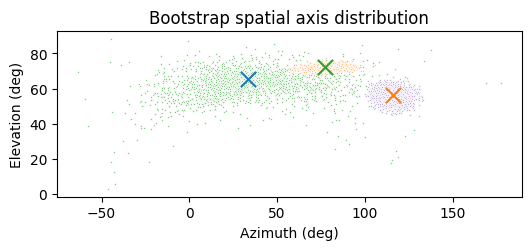

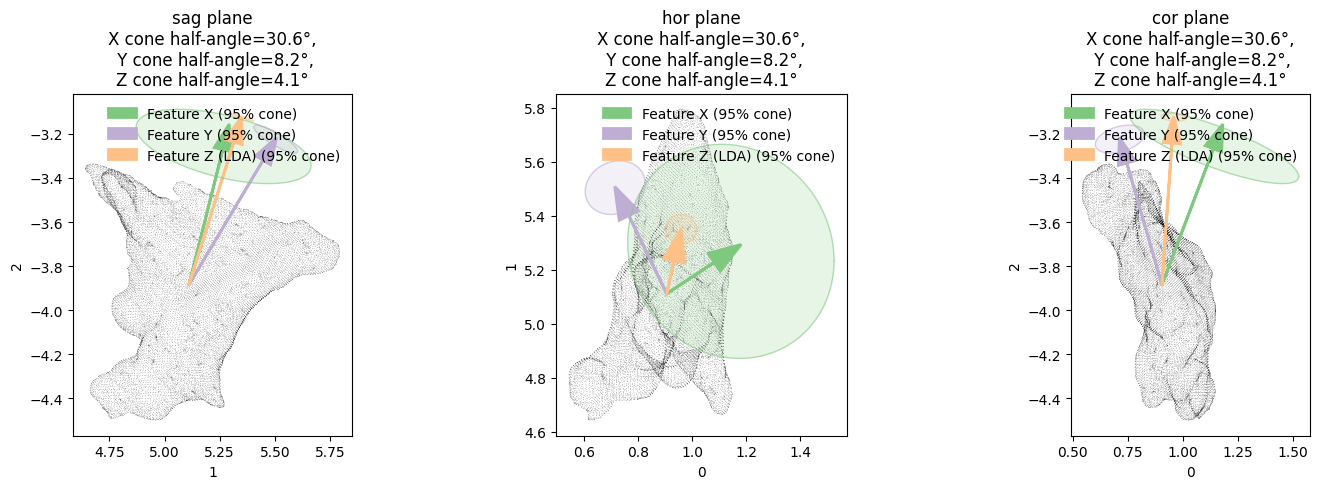

In [21]:
# flip LDA axis if needed to align with linear axes (mostly for visualization consistency, not a statistical requirement)


fig, ax = plt.subplots(figsize=(6, 6))
ax = plot_vector_distribution_az_el_2d(axis_boot_x, axis_x, colors['x'], ax=ax)
ax = plot_vector_distribution_az_el_2d(axis_boot_y, axis_y, colors['y'], ax=ax)
ax = plot_vector_distribution_az_el_2d(axis_boot_z, axis_z, colors['z'], ax=ax)
fig.savefig(os.path.join(target_folder, "spatial_axis_bootstrap_scatter.svg"), dpi=300)
fig.savefig(os.path.join(target_folder, "spatial_axis_bootstrap_scatter.pdf"), dpi=300)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scale = 0.8
head_length = 0.12
head_width = 0.08

for plane, ax in zip(planes.keys(), axes):
    # mesh
    # for c in mesh_contours[plane]:
    #     ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    # ax.scatter(coord_x[:, planes[plane][0]], coord_x[:, planes[plane][1]], s=20, color='gray', alpha=0.5, label='Coordinates')
    ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], s=0.1, edgecolor = 'none', color = 'k')
    dims = planes[plane]  # e.g. (0,1)

    # choose origin
    origin = np.mean(mesh_vertices_mm[:, [dims[0], dims[1]]], axis=0)

    # X axis + cone
    out_x = plot_projected_arrow_with_cone(
        ax,
        origin,
        axis_x,
        axis_boot_x,
        dims,
        color=colors['x'],
        scale=scale,
        head_width=head_width,
        head_length=head_length,
        cone_q=95,
        cone_alpha=0.18,
        label=f'Feature X ({0.95:.0%} cone)'
    )

    # Y axis + cone
    out_y = plot_projected_arrow_with_cone(
        ax,
        origin,
        axis_y,
        axis_boot_y,
        dims,
        color=colors['y'],
        scale=scale,
        head_width=head_width,
        head_length=head_length,
        cone_q=95,
        cone_alpha=0.18,
        label=f'Feature Y ({0.95:.0%} cone)'
    )

    out_z = plot_projected_arrow_with_cone(
        ax,
        origin,
        axis_z,
        axis_boot_z,
        dims,
        color=colors['z'],
        scale=scale,
        head_width=head_width,
        head_length=head_length,
        cone_q=95,
        cone_alpha=0.18,
        label=f'Feature Z (LDA) ({0.95:.0%} cone)'
    )

    ax.set_title(
        f"{plane} plane\n"
        f"X cone half-angle={out_x['half_angle_deg']:.1f}°,\n "
        f"Y cone half-angle={out_y['half_angle_deg']:.1f}°,\n"
        f"Z cone half-angle={out_z['half_angle_deg']:.1f}°"
    )
    ax.set_xlabel(str(dims[0]))
    ax.set_ylabel(str(dims[1]))
    ax.set_aspect('equal')
    ax.legend(frameon=False)

plt.tight_layout()
# plt.show()
fig.savefig(os.path.join(target_folder, "spatial_axis_with_CI_cone.svg"), dpi=300)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


def plot_direction_difference(res, ci_level=0.95, ax=None, print_stats=True):
    """
    Plot bootstrap distribution of the 2D directional difference and the
    observed 2D deviation of y from x.

    Parameters
    ----------
    res : dict
        Output from compare_bootstrap_directions()
    ci_level : float
        Confidence level for the 2D ellipse.
    ax : matplotlib axis or None
    print_stats : bool
        Whether to print summary statistics.

    Returns
    -------
    ax : matplotlib axis
    """
    d_boot = np.asarray(res["d_boot"])
    d_obs = np.asarray(res["d_obs"])
    cov = np.asarray(res["cov_2d"])
    mean_boot = np.asarray(res.get("mean_boot", d_boot.mean(axis=0)))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # bootstrap cloud
    ax.scatter(
        d_boot[:, 0],
        d_boot[:, 1],
        s=5,
        alpha=0.25,
        label="Bootstrap difference",
        color="k",
        edgecolor='none',
    )

    # observed 2D deviation of y from x
    ax.scatter(
        d_obs[0],
        d_obs[1],
        s=120,
        marker="x",
        linewidths=2.5,
        label="Observed y-from-x deviation",
        zorder=5,
    )

    # bootstrap mean
    ax.scatter(
        mean_boot[0],
        mean_boot[1],
        s=70,
        marker="o",
        label="Bootstrap mean",
        zorder=4,
    )

    # origin = no directional difference
    ax.scatter(
        0, 0,
        s=60,
        marker="+",
        linewidths=2,
        label="No difference (0,0)",
        zorder=4,
    )

    # axes
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    # CI ellipse centered at bootstrap mean
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    r2 = chi2.ppf(ci_level, df=2)
    radii = np.sqrt(vals * r2)

    theta = np.linspace(0, 2 * np.pi, 300)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    ellipse = vecs @ np.diag(radii) @ circle
    ellipse = ellipse + mean_boot[:, None]

    # ax.plot(
    #     ellipse[0],
    #     ellipse[1],
    #     linewidth=2,
    #     label=f"{int(ci_level * 100)}% CI ellipse",
    #     zorder=3,
    # )

    ax.fill_between(
        ellipse[0],
        ellipse[1],
        color="gray",
        alpha=0.2,
        zorder=2,
        edgecolor='none',

    )

    ax.set_xlabel("Deviation along e1")
    ax.set_ylabel("Deviation along e2")
    ax.set_aspect("equal")

    ax.set_title(
        f"2D directional difference: y vs x\n"
        f"p_boot = {res['p_boot']:.4g}, p_chi2 = {res['p_chi2']:.4g}, "
        f"angle = {res['angle_deg']:.2f}°"
    )
    ax.legend(frameon=False)

    if print_stats:
        print("=== Direction comparison stats ===")
        print(f"Observed angle (deg): {res['angle_deg']:.6f}")
        print(f"Observed 2D deviation d_obs: [{d_obs[0]:.6f}, {d_obs[1]:.6f}]")
        print(f"Bootstrap mean: [{mean_boot[0]:.6f}, {mean_boot[1]:.6f}]")
        print("Bootstrap covariance:")
        print(cov)
        print(f"W_obs: {res['W_obs']:.6f}")
        print(f"p_boot: {res['p_boot']:.6g}")
        print(f"p_chi2: {res['p_chi2']:.6g}")
        print(f"n_boot_valid: {res['n_boot_valid']}")

        # Mahalanobis distance of observed point from bootstrap mean
        cov_inv = np.linalg.inv(cov)
        delta = d_obs - mean_boot
        maha2 = float(delta.T @ cov_inv @ delta)
        inside = maha2 <= r2
        print(f"Observed point inside {int(ci_level*100)}% CI ellipse: {inside}")

    return ax

b_x: [0.34495102 0.2281558  0.91046896]
b_y: [-0.24100181  0.49669996  0.83379091]
b_z: [0.06710185 0.29909511 0.95186105]
b_x_boot shape: (2000, 3)
b_y_boot shape: (2000, 3)
b_z_boot shape: (2000, 3)
=== Direction comparison stats ===
Observed angle (deg): 37.876880
Observed 2D deviation d_obs: [0.613967, -0.000000]
Bootstrap mean: [0.601593, -0.008586]
Bootstrap covariance:
[[ 0.05788538 -0.01303137]
 [-0.01303137  0.02184486]]
W_obs: 7.522311
p_boot: 0.0380962
p_chi2: 0.0232569
n_boot_valid: 10000
Observed point inside 95% CI ellipse: True
=== Direction comparison stats ===
Observed angle (deg): 16.659162
Observed 2D deviation d_obs: [0.286678, 0.000000]
Bootstrap mean: [0.275587, 0.004372]
Bootstrap covariance:
[[ 0.04763743 -0.02023077]
 [-0.02023077  0.02851313]]
W_obs: 2.469238
p_boot: 0.262974
p_chi2: 0.290946
n_boot_valid: 10000
Observed point inside 95% CI ellipse: True
=== Direction comparison stats ===
Observed angle (deg): 22.174000
Observed 2D deviation d_obs: [0.377421, 

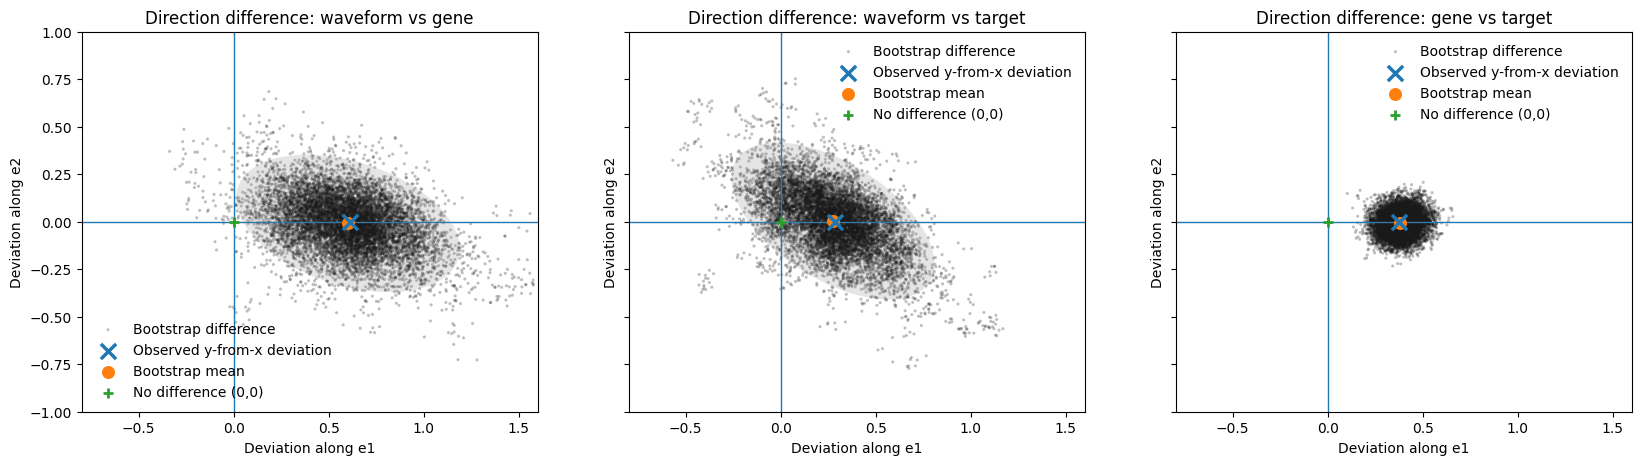

In [29]:
b_x = res_boot_x["axis_unit"]
b_y = res_boot_y["axis_unit"]
b_z = res_boot_z["axis_unit"]

b_x_boot = res_boot_x["axis_boot"]
b_y_boot = res_boot_y["axis_boot"]
b_z_boot = res_boot_z["axis_boot"]

print("b_x:", b_x)
print("b_y:", b_y)
print("b_z:", b_z)
print("b_x_boot shape:", b_x_boot.shape)
print("b_y_boot shape:", b_y_boot.shape)
print("b_z_boot shape:", b_z_boot.shape)

# 4) compare directions
res_cmp_xy = compare_bootstrap_directions(
    b_x,
    b_y,
    b_x_boot,
    b_y_boot,
    assume_paired=False,
    flip_to_observed=True,
)

res_cmp_xz = compare_bootstrap_directions(
    b_x,
    b_z,
    b_x_boot,
    b_z_boot,
    assume_paired=False,
    flip_to_observed=True,
)

res_cmp_yz = compare_bootstrap_directions(
    b_y,
    b_z,
    b_y_boot,
    b_z_boot,
    assume_paired=False,
    flip_to_observed=True,
)


# print("Observed angle (deg):", res_cmp["angle_deg"])
# print("Observed 2D difference:", res_cmp["d_obs"])
# print("Bootstrap p-value:", res_cmp["p_boot"])
# print("Chi-square p-value:", res_cmp["p_chi2"])

# 5) plot 2D distribution of directional difference
# plot_direction_difference(res_cmp)
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True, sharex=True)
plot_direction_difference(res_cmp_xy, ci_level=0.95, print_stats=True, ax=axes[0])
plt.xlim(-0.8, 1.6)
plt.ylim(-1, 1)
axes[0].set_title("Direction difference: waveform vs gene")
# plt.savefig(os.path.join(target_folder, "direction_difference_wf_gene.svg"), dpi=300)
plot_direction_difference(res_cmp_xz, ci_level=0.95, print_stats=True, ax=axes[1])
axes[1].set_title("Direction difference: waveform vs target")
plt.xlim(-0.8, 1.6)
plt.ylim(-1, 1)
# plt.savefig(os.path.join(target_folder, "direction_difference_wf_target.svg"), dpi=300)
plot_direction_difference(res_cmp_yz, ci_level=0.95, print_stats=True, ax=axes[2])
plt.xlim(-0.8, 1.6)
plt.ylim(-1, 1)
axes[2].set_title("Direction difference: gene vs target")
plt.savefig(os.path.join(target_folder, "direction_difference_combinedt.svg"), dpi=300)


## Load behavior dataframe

In [24]:
reward_colors = LinearSegmentedColormap.from_list('outcome', [(0.0, 'magenta'), (0.5, 'gray'), (1.0, 'cyan')])
hit_colors = LinearSegmentedColormap.from_list('hit', [(0.0, 'blue'), (0.5, 'gray'), (1.0, 'orange')])
switch_colors = LinearSegmentedColormap.from_list('switch', [(0.0, 'green'), (0.5, 'gray'), (1.0, 'purple')])
feature_map = {
            'T_baseline_svs_hit': switch_colors,
            'T_response_svs_hit': switch_colors,
            'T_outcome_com_mc': reward_colors,
            'T_outcome_l_mc': reward_colors, 
            'T_baseline_hit_all': hit_colors, 
            'T_response_hit_all': hit_colors
            }

In [25]:
beh_file = '/root/capsule/scratch/manuscript/F_ephys_beh_action&outcome/features_combined_beh_all.pkl'
with open(beh_file, 'rb') as f:
    beh_data = pickle.load(f)

In [26]:
def get_regression_CI(x, y):
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample

    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1)

    # Prediction grid
    reg = LinearRegression().fit(x, y)

    x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    X_fit = x_fit.reshape(-1, 1)
    y_fit = reg.predict(X_fit)

    # --- Compute confidence interval ---
    n_boot = 1000
    n = len(x)
    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean) ** 2)

    # res
    y_pred = reg.predict(x)
    residuals = y - y_pred
    s_err = np.sqrt(np.sum(residuals ** 2) / (n - 2))

    t_val = stats.t.ppf(0.975, df=n-2)

    conf = t_val * s_err * np.sqrt(1/n + (x_fit - x_mean) ** 2 / Sxx)

    # plot
    ci_lower = y_fit - conf
    ci_upper = y_fit + conf


    return y_fit, x_fit, ci_lower, ci_upper

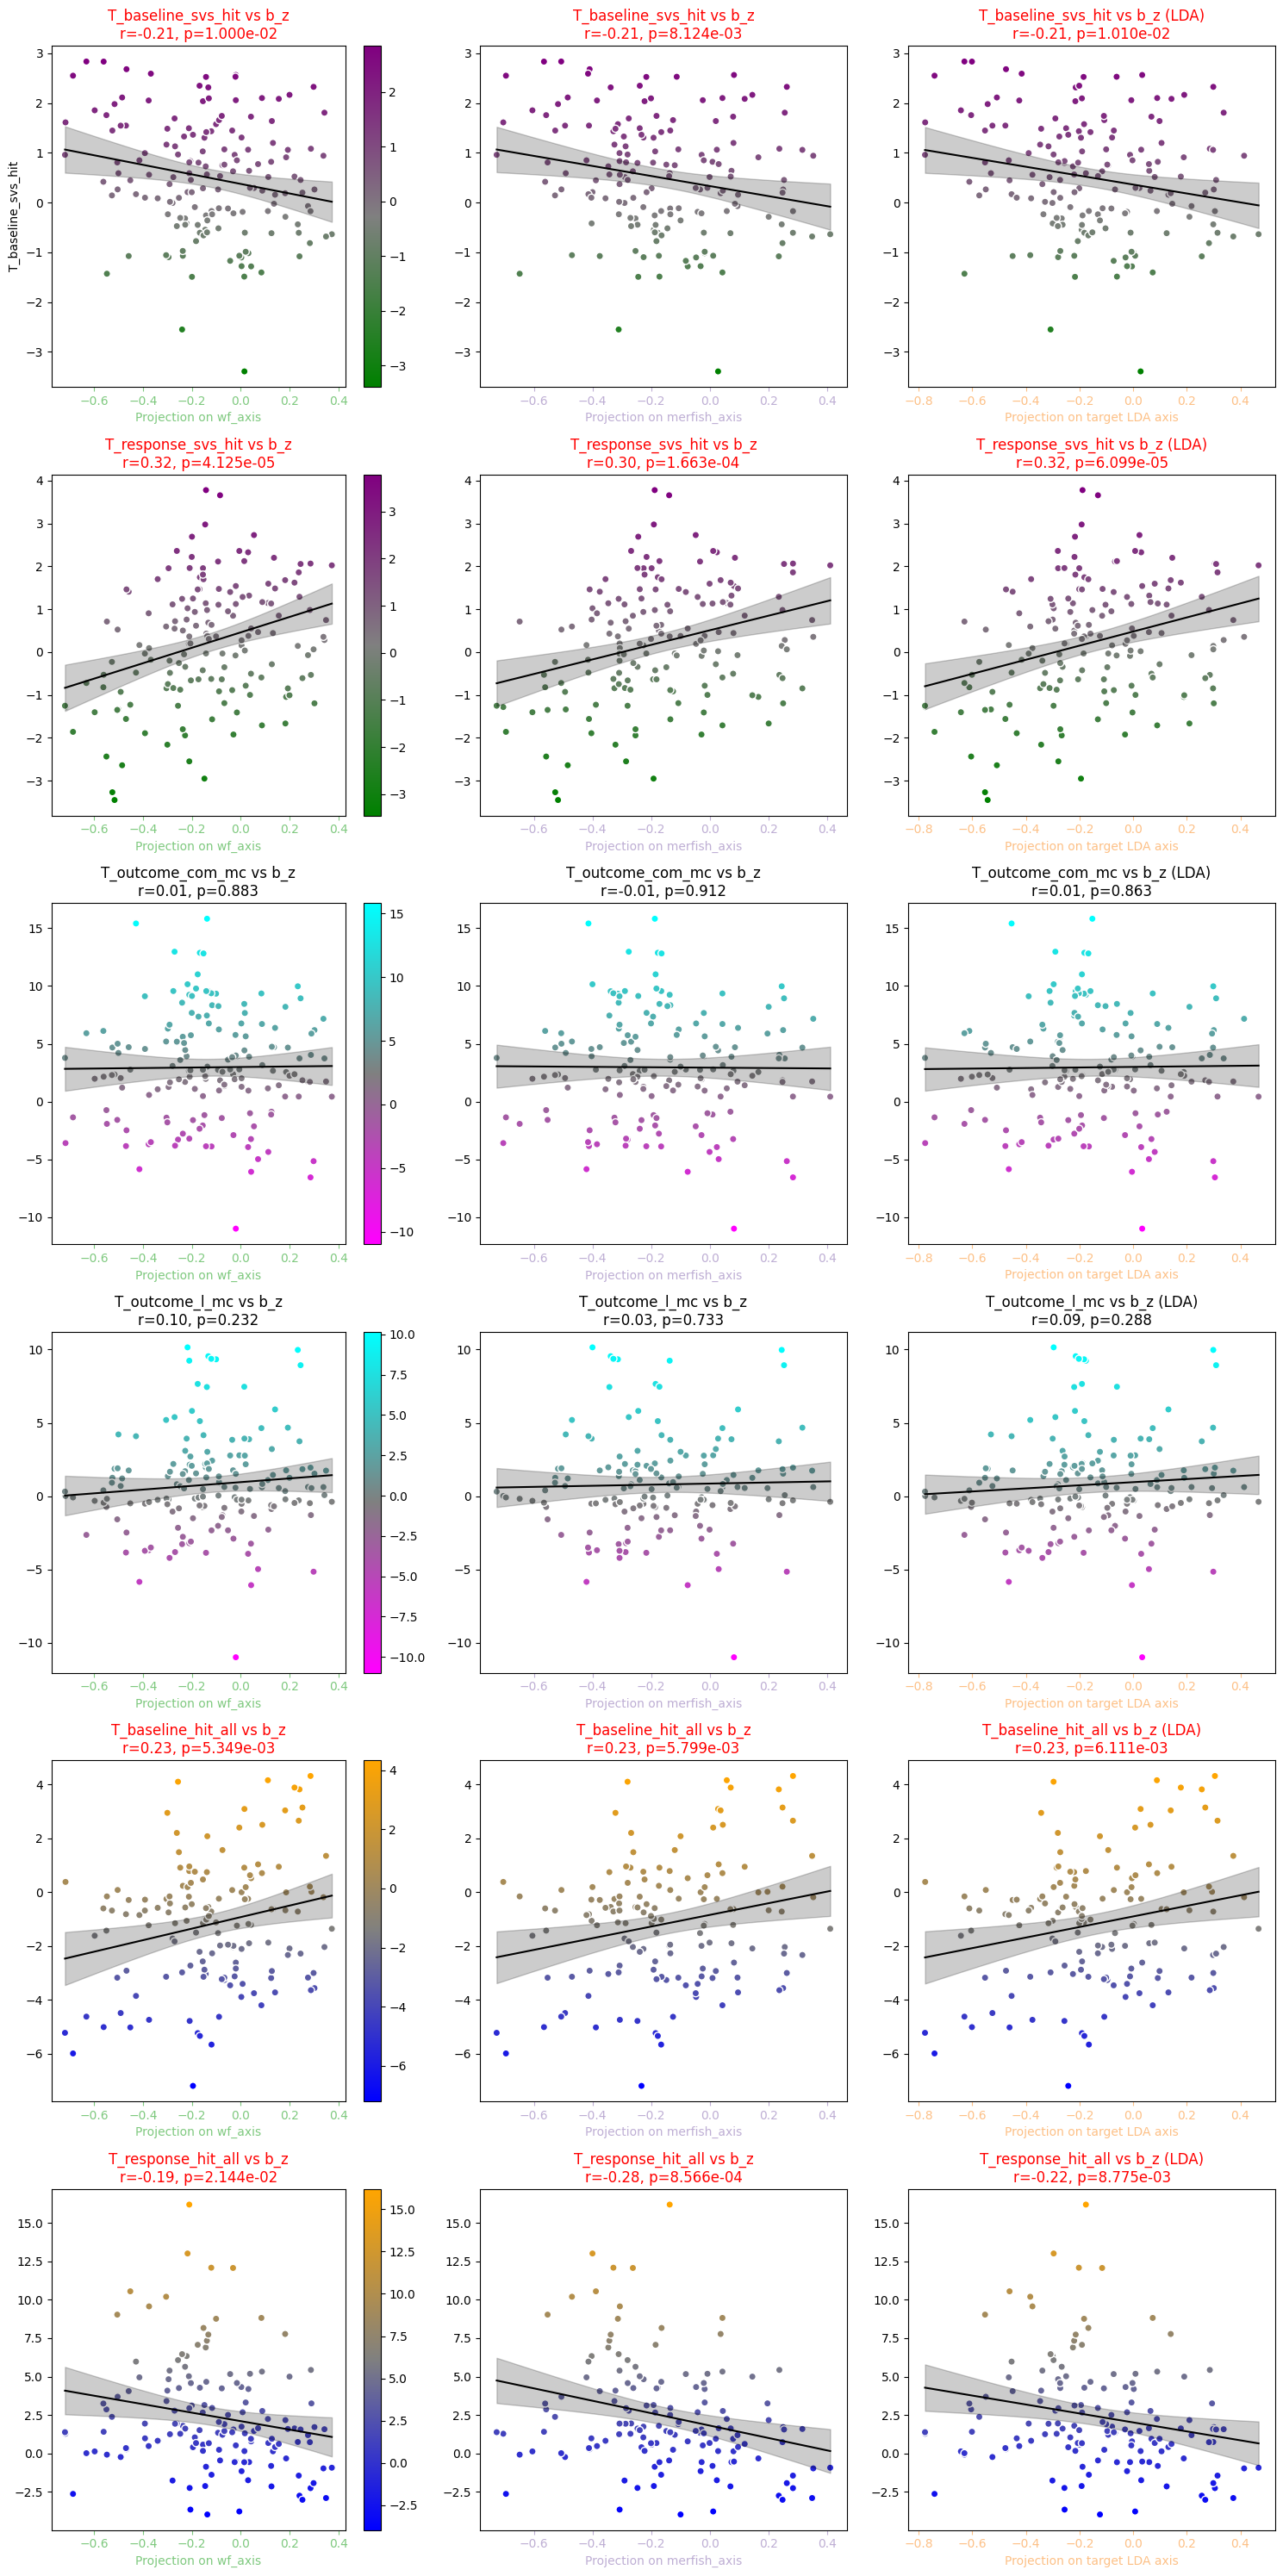

In [27]:
# import pearson r
from scipy.stats import pearsonr
features = feature_map.keys()
ccfs = beh_data[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere
ccf_centered = ccfs - np.mean(mesh_vertices_mm, axis=0)

fig, axes = plt.subplots(len(features), 3, figsize=(15, 5 * len(features)))
for i, feature in enumerate(features):
    feature_values = beh_data[feature].values
    # project to b_x
    proj_x = np.dot(ccf_centered, res_boot_x["axis_unit"])
    proj_y = np.dot(ccf_centered, res_boot_y["axis_unit"])
    proj_z = np.dot(ccf_centered, res_boot_z["axis_unit"])

    ax = axes[i, 0]
    sc = ax.scatter(proj_x, feature_values, c=feature_values, cmap=feature_map[feature], edgecolor='w', alpha=1)
    # add regression line with CI

    # correlation
    valid_mask = ~np.isnan(proj_x) & ~np.isnan(feature_values)
    if np.sum(valid_mask) > 2:
        r, p = pearsonr(proj_x[valid_mask], feature_values[valid_mask])
        if p<0.05:
            ax.set_title(f"{feature} vs b_z\nr={r:.2f}, p={p:.3e}", color='r')
        else:
            ax.set_title(f"{feature} vs b_z\nr={r:.2f}, p={p:.3g}")
        y_fit, x_fit, ci_lower, ci_upper = get_regression_CI(proj_x[valid_mask], feature_values[valid_mask])
        ax.plot(x_fit, y_fit, color='black', label='Fit')
        ax.fill_between(x_fit, ci_lower, ci_upper, color='black', alpha=0.2, label='95% CI')
    else:
        ax.set_title(f"{feature} vs b_x\nNot enough valid points")
    plt.colorbar(sc, ax=ax)

    ax.set_xlabel("Projection on wf_axis")
    if i == 0:
        ax.set_ylabel(feature)

    ax.tick_params(axis='x', colors=colors['x'])
    ax.xaxis.label.set_color(colors['x'])


    
    ax = axes[i, 1]
    sc = ax.scatter(proj_y, feature_values, c=feature_values, cmap=feature_map[feature], edgecolor='w', alpha=1)
    valid_mask = ~np.isnan(proj_y) & ~np.isnan(feature_values)
    if np.sum(valid_mask) > 2:
        r, p = pearsonr(proj_y[valid_mask], feature_values[valid_mask])
        y_fit, x_fit, ci_lower, ci_upper = get_regression_CI(proj_y[valid_mask], feature_values[valid_mask])
        ax.plot(x_fit, y_fit, color='black', label='Fit')
        ax.fill_between(x_fit, ci_lower, ci_upper, color='black', alpha=0.2, label='95% CI')
        if p<0.05:
            ax.set_title(f"{feature} vs b_z\nr={r:.2f}, p={p:.3e}", color='r')
        else:
            ax.set_title(f"{feature} vs b_z\nr={r:.2f}, p={p:.3g}")
    else:
        ax.set_title(f"{feature} vs b_y\nNot enough valid points")

    ax.set_xlabel("Projection on merfish_axis")
    ax.tick_params(axis='x', colors=colors['y'])
    ax.xaxis.label.set_color(colors['y'])

    ax = axes[i, 2]
    sc = ax.scatter(proj_z, feature_values, c=feature_values, cmap=feature_map[feature], edgecolor='w', alpha=1)
    valid_mask = ~np.isnan(proj_z) & ~np.isnan(feature_values)
    if np.sum(valid_mask) > 2:
        r, p = pearsonr(proj_z[valid_mask], feature_values[valid_mask])
        y_fit, x_fit, ci_lower, ci_upper = get_regression_CI(proj_z[valid_mask], feature_values[valid_mask])
        ax.plot(x_fit, y_fit, color='black', label='Fit')
        ax.fill_between(x_fit, ci_lower, ci_upper, color='black', alpha=0.2, label='95% CI')
        if p<0.05:
            ax.set_title(f"{feature} vs b_z (LDA)\nr={r:.2f}, p={p:.3e}", color='r')
        else:
            ax.set_title(f"{feature} vs b_z (LDA)\nr={r:.2f}, p={p:.3g}")
    else:
        ax.set_title(f"{feature} vs b_z (LDA)\nNot enough valid points")
    ax.set_xlabel("Projection on target LDA axis")
    ax.tick_params(axis='x', colors=colors['z'])
    ax.xaxis.label.set_color(colors['z'])
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(target_folder, "beh_feature_vs_primary_projection_correlations.svg"), dpi=300)

